# Test Prediction Visualizations

Creates slide-ready visualizations from cached test-set predictions generated by `predict_morphology_test.py`. No model loading and no ODE sampling happens in this notebook.

In [1]:
from __future__ import annotations

from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import gaussian_kde, wasserstein_distance

sns.set_theme(style="whitegrid", context="talk")

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
PREDICTION_DIR = PROJECT_ROOT / "outputs" / "test_predictions"
FIGURE_DIR = PROJECT_ROOT / "outputs" / "test_prediction_visuals"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

BEST_MODEL = "50pc_film_model"
MODEL_ORDER = [
    "unconditioned",
    "50pc_concat_model",
    "full_film_model",
    "30pc_film",
    "50pc_film_model",
]
MODEL_LABELS = {
    "unconditioned": "Unconditioned",
    "50pc_concat_model": "PCA 50 + Concat",
    "full_film_model": "Full + FiLM",
    "30pc_film": "PCA 30 + FiLM",
    "50pc_film_model": "PCA 50 + FiLM",
}
VAL_NW1 = {
    "unconditioned": 0.117,
    "50pc_concat_model": 0.105,
    "full_film_model": 0.108,
    "30pc_film": 0.092,
    "50pc_film_model": 0.092,
}

FEATURES_FOR_KDE = [
    "Area",
    "Eccentricity",
    "HuMoment_0",
    "InertiaTensorEigenvalues_1",
]

REAL_COLOR = "#2563EB"
BEST_COLOR = "#DC2626"
BAR_COLOR = "#F97316"
GRAY = "#6B7280"

print(f"Prediction dir: {PREDICTION_DIR}")
print(f"Figure dir:     {FIGURE_DIR}")

Prediction dir: /Users/hannesneumann/Repositories/conditional-flow-matching-seminar/outputs/test_predictions
Figure dir:     /Users/hannesneumann/Repositories/conditional-flow-matching-seminar/outputs/test_prediction_visuals


## Load Cached Predictions

In [2]:
def load_prediction(model_name: str) -> dict:
    path = PREDICTION_DIR / model_name / "predictions.npz"
    if not path.exists():
        raise FileNotFoundError(
            f"Missing predictions for {model_name!r}: {path}. "
            "Run predict_morphology_test.py first."
        )
    arr = np.load(path, allow_pickle=True)
    return {
        "model": model_name,
        "path": path,
        "y_real": arr["y_real"].astype(np.float64),
        "y_pred": arr["y_pred"].astype(np.float64),
        "leiden": arr["leiden"].astype(str),
        "obs_names": arr["obs_names"].astype(str),
        "morph_cols": list(arr["morph_cols"]),
    }

predictions = {name: load_prediction(name) for name in MODEL_ORDER}
morph_cols = predictions[BEST_MODEL]["morph_cols"]

for name, pred in predictions.items():
    assert pred["morph_cols"] == morph_cols, f"Morphology columns differ for {name}"
    print(f"{MODEL_LABELS[name]:18s} {pred['y_pred'].shape[0]:7,d} cells | {pred['y_pred'].shape[1]} features")

feature_to_idx = {feature: i for i, feature in enumerate(morph_cols)}
y_real = predictions[BEST_MODEL]["y_real"]
y_best = predictions[BEST_MODEL]["y_pred"]


Unconditioned       19,471 cells | 56 features
PCA 50 + Concat     19,471 cells | 56 features
Full + FiLM         19,471 cells | 56 features
PCA 30 + FiLM       19,471 cells | 56 features
PCA 50 + FiLM       19,471 cells | 56 features


## Metrics: nW1 per Model and Feature

In [3]:
def w1_feature_table(model_name: str, eps: float = 1e-8) -> pd.DataFrame:
    pred = predictions[model_name]
    y_real = pred["y_real"]
    y_gen = pred["y_pred"]
    rows = []
    for i, feature in enumerate(morph_cols):
        real = y_real[:, i]
        gen = y_gen[:, i]
        real_std = float(np.std(real))
        w1 = float(wasserstein_distance(real, gen))
        rows.append({
            "model": model_name,
            "model_label": MODEL_LABELS.get(model_name, model_name),
            "feature": feature,
            "real_mean": float(np.mean(real)),
            "gen_mean": float(np.mean(gen)),
            "real_std": real_std,
            "gen_std": float(np.std(gen)),
            "w1": w1,
            "normalized_w1": w1 / max(real_std, eps),
        })
    return pd.DataFrame(rows)

feature_metrics = pd.concat([w1_feature_table(name) for name in MODEL_ORDER], ignore_index=True)
summary = (
    feature_metrics
    .groupby(["model", "model_label"], as_index=False)
    .agg(
        mean_w1=("w1", "mean"),
        median_w1=("w1", "median"),
        mean_normalized_w1=("normalized_w1", "mean"),
        median_normalized_w1=("normalized_w1", "median"),
    )
)
summary["nW1_val"] = summary["model"].map(VAL_NW1)
summary["delta_test_minus_val"] = summary["mean_normalized_w1"] - summary["nW1_val"]
summary["order"] = summary["model"].map({name: i for i, name in enumerate(MODEL_ORDER)})
summary = summary.sort_values("order").drop(columns="order")

feature_metrics.to_csv(FIGURE_DIR / "test_feature_metrics.csv", index=False)
summary.to_csv(FIGURE_DIR / "test_model_summary.csv", index=False)
display(summary[["model_label", "nW1_val", "mean_normalized_w1", "delta_test_minus_val"]])

,model_label,nW1_val,mean_normalized_w1,delta_test_minus_val
4,Unconditioned,0.117,0.115441,-0.001559
1,PCA 50 + Concat,0.105,0.106819,0.001819
3,Full + FiLM,0.108,0.108406,0.000406
0,PCA 30 + FiLM,0.092,0.099598,0.007598
2,PCA 50 + FiLM,0.092,0.097058,0.005058


## Slide 11: KDE Real vs. Best Model

Saved /Users/hannesneumann/Repositories/conditional-flow-matching-seminar/outputs/test_prediction_visuals/slide11_kde_real_vs_pca50_film.png
Saved /Users/hannesneumann/Repositories/conditional-flow-matching-seminar/outputs/test_prediction_visuals/slide11_kde_real_vs_pca50_film.svg


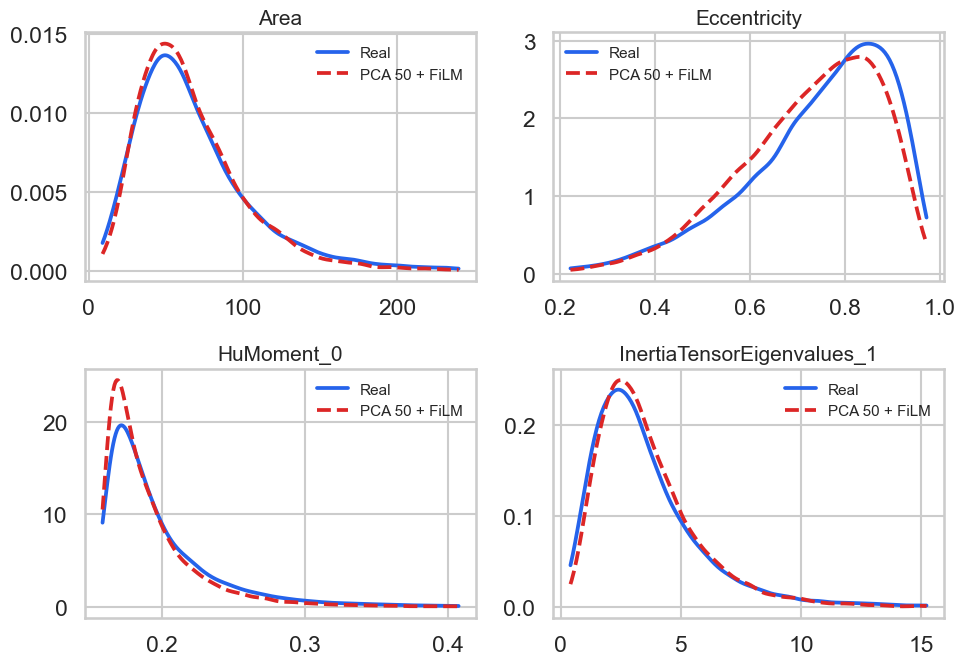

In [22]:
def finite_series(values: np.ndarray) -> np.ndarray:
    values = np.asarray(values, dtype=np.float64)
    return values[np.isfinite(values)]

fig, axes = plt.subplots(2, 2, figsize=(10, 7))
axes = axes.flatten()

for ax, feature in zip(axes, FEATURES_FOR_KDE):
    idx = feature_to_idx[feature]
    real_vals = finite_series(y_real[:, idx])
    gen_vals = finite_series(y_best[:, idx])

    lo, hi = np.quantile(real_vals, [0.005, 0.995])
    if np.isclose(lo, hi):
        lo, hi = real_vals.min(), real_vals.max()
    x_range = np.linspace(lo, hi, 300)

    kde_real = gaussian_kde(real_vals)
    kde_gen = gaussian_kde(gen_vals)

    ax.plot(x_range, kde_real(x_range), label="Real", color=REAL_COLOR, linewidth=2.7)
    ax.plot(
        x_range,
        kde_gen(x_range),
        label="PCA 50 + FiLM",
        color=BEST_COLOR,
        linewidth=2.7,
        linestyle="--",
    )
    ax.set_title(feature, fontsize=15)
    ax.set_ylabel("")
    ax.legend(frameon=False, fontsize=11)

# fig.suptitle("Morphology marginals on held-out test set", fontsize=18, y=1.02)
plt.tight_layout()
for suffix in ["png", "svg"]:
    path = FIGURE_DIR / f"slide11_kde_real_vs_pca50_film.{suffix}"
    fig.savefig(path, dpi=300, bbox_inches="tight")
    print(f"Saved {path}")
plt.show()

## Slide 12: Val vs. OOD Summary Table and Optional Barplot

In [5]:
slide12_table = pd.DataFrame([
    {
        "Model": "Unconditioned",
        "Conditioning": "-",
        "Mechanism": "-",
        "nW1 (Val)": 0.117,
        "nW1 (OOD/Test)": float(summary.loc[summary["model"] == "unconditioned", "mean_normalized_w1"].iloc[0]),
    },
    {
        "Model": "PCA 50 + Concat",
        "Conditioning": "50 PCs",
        "Mechanism": "Concat",
        "nW1 (Val)": 0.105,
        "nW1 (OOD/Test)": float(summary.loc[summary["model"] == "50pc_concat_model", "mean_normalized_w1"].iloc[0]),
    },
    {
        "Model": "Full + FiLM",
        "Conditioning": "540 probes",
        "Mechanism": "FiLM",
        "nW1 (Val)": 0.108,
        "nW1 (OOD/Test)": float(summary.loc[summary["model"] == "full_film_model", "mean_normalized_w1"].iloc[0]),
    },
    {
        "Model": "PCA 30 + FiLM",
        "Conditioning": "30 PCs",
        "Mechanism": "FiLM",
        "nW1 (Val)": 0.092,
        "nW1 (OOD/Test)": float(summary.loc[summary["model"] == "30pc_film", "mean_normalized_w1"].iloc[0]),
    },
    {
        "Model": "PCA 50 + FiLM",
        "Conditioning": "50 PCs",
        "Mechanism": "FiLM",
        "nW1 (Val)": 0.092,
        "nW1 (OOD/Test)": float(summary.loc[summary["model"] == "50pc_film_model", "mean_normalized_w1"].iloc[0]),
    },
])
slide12_table["Delta"] = slide12_table["nW1 (OOD/Test)"] - slide12_table["nW1 (Val)"]
slide12_table.to_csv(FIGURE_DIR / "slide12_val_vs_test_table.csv", index=False)
display(slide12_table.style.format({"nW1 (Val)": "{:.3f}", "nW1 (OOD/Test)": "{:.3f}", "Delta": "{:+.3f}"}))

,Model,Conditioning,Mechanism,nW1 (Val),nW1 (OOD/Test),Delta
0,Unconditioned,-,-,0.117,0.115,-0.002
1,PCA 50 + Concat,50 PCs,Concat,0.105,0.107,+0.002
2,Full + FiLM,540 probes,FiLM,0.108,0.108,+0.000
3,PCA 30 + FiLM,30 PCs,FiLM,0.092,0.100,+0.008
4,PCA 50 + FiLM,50 PCs,FiLM,0.092,0.097,+0.005


Saved /Users/hannesneumann/Repositories/conditional-flow-matching-seminar/outputs/test_prediction_visuals/slide12_val_vs_test_barplot.png
Saved /Users/hannesneumann/Repositories/conditional-flow-matching-seminar/outputs/test_prediction_visuals/slide12_val_vs_test_barplot.svg


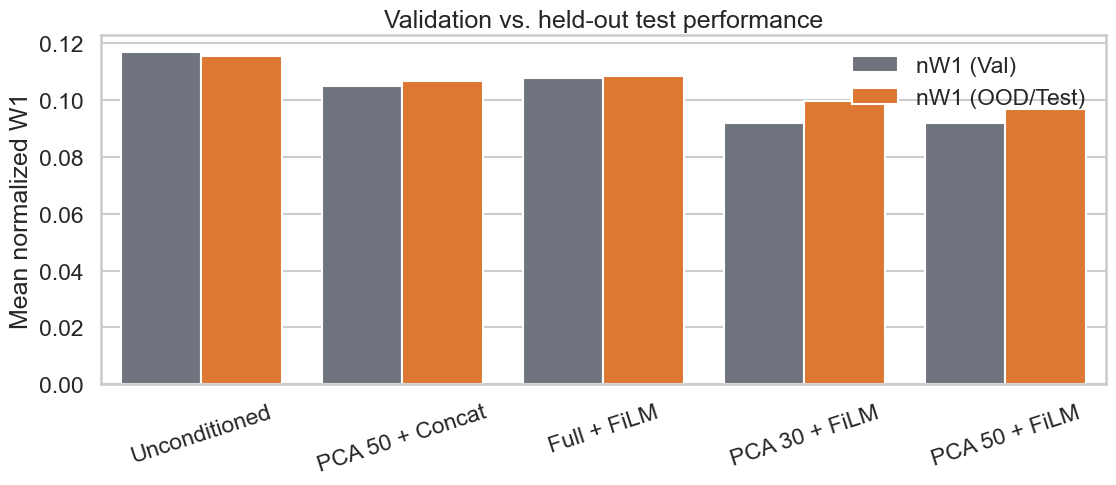

In [6]:
bar_df = slide12_table.melt(
    id_vars="Model",
    value_vars=["nW1 (Val)", "nW1 (OOD/Test)"],
    var_name="Split",
    value_name="mean nW1",
)

fig, ax = plt.subplots(figsize=(11.5, 5.2))
sns.barplot(data=bar_df, x="Model", y="mean nW1", hue="Split", palette=[GRAY, BAR_COLOR], ax=ax)
ax.set_xlabel("")
ax.set_ylabel("Mean normalized W1")
ax.set_title("Validation vs. held-out test performance")
ax.tick_params(axis="x", rotation=18)
ax.legend(frameon=False, title="")
plt.tight_layout()
for suffix in ["png", "svg"]:
    path = FIGURE_DIR / f"slide12_val_vs_test_barplot.{suffix}"
    fig.savefig(path, dpi=300, bbox_inches="tight")
    print(f"Saved {path}")
plt.show()

## Slide 13A: Correlation Structure Real vs. Generated

Saved /Users/hannesneumann/Repositories/conditional-flow-matching-seminar/outputs/test_prediction_visuals/slide13_correlation_matrices_pca50_film.png
Saved /Users/hannesneumann/Repositories/conditional-flow-matching-seminar/outputs/test_prediction_visuals/slide13_correlation_matrices_pca50_film.svg


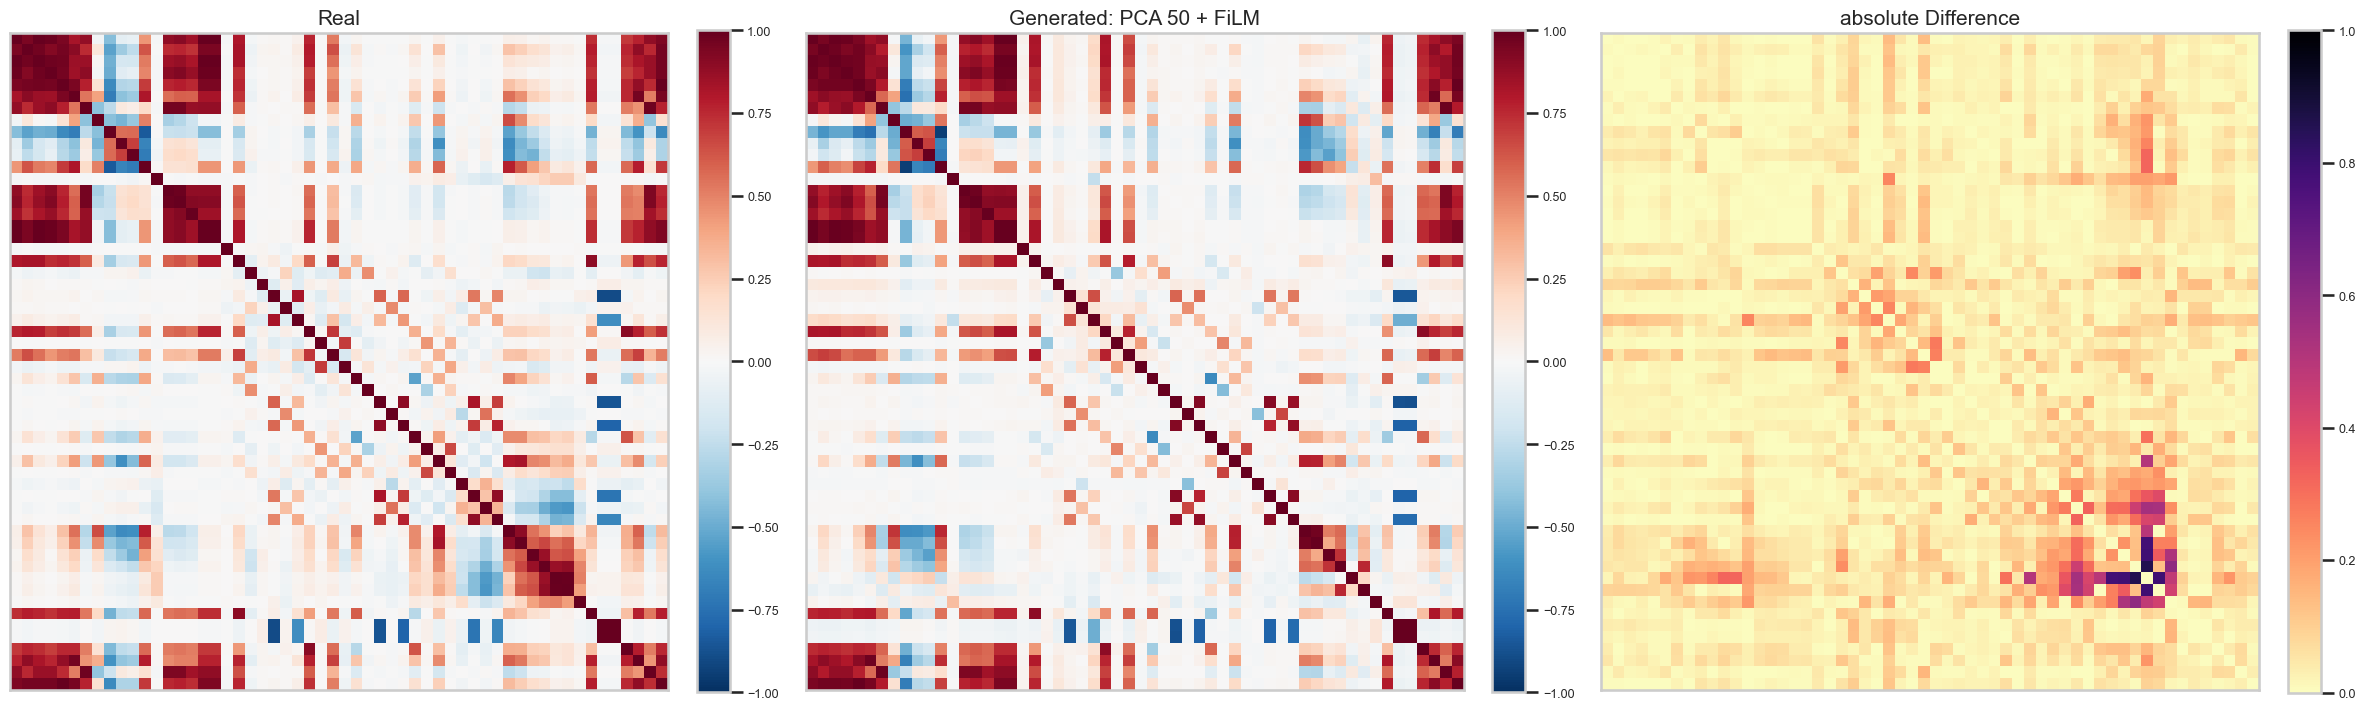

In [18]:
corr_real = np.corrcoef(y_real.T)
corr_gen = np.corrcoef(y_best.T)
corr_diff = np.abs(corr_real - corr_gen)

fig, axes = plt.subplots(1, 3, figsize=(24, 8.4))
plots = [
    (corr_real, "Real", -1, 1, "RdBu_r"),
    (corr_gen, "Generated: PCA 50 + FiLM", -1, 1, "RdBu_r"),
    (corr_diff, "absolute Difference", 0, 1, "magma_r"),
]

for ax, (matrix, title, vmin, vmax, cmap) in zip(axes, plots):
    im = ax.imshow(matrix, vmin=vmin, vmax=vmax, cmap=cmap, aspect="equal")
    ax.set_title(title, fontsize=15)
    ax.set_xticks([])
    ax.set_yticks([])
    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.ax.tick_params(labelsize=9)

# fig.suptitle("Feature correlation structure on held-out test set", fontsize=18, y=1.03)
plt.tight_layout()
for suffix in ["png", "svg"]:
    path = FIGURE_DIR / f"slide13_correlation_matrices_pca50_film.{suffix}"
    fig.savefig(path, dpi=300, bbox_inches="tight")
    print(f"Saved {path}")
plt.show()

Saved /Users/hannesneumann/Repositories/conditional-flow-matching-seminar/outputs/test_prediction_visuals/slide13_correlation_matrices_labeled_pca50_film.png


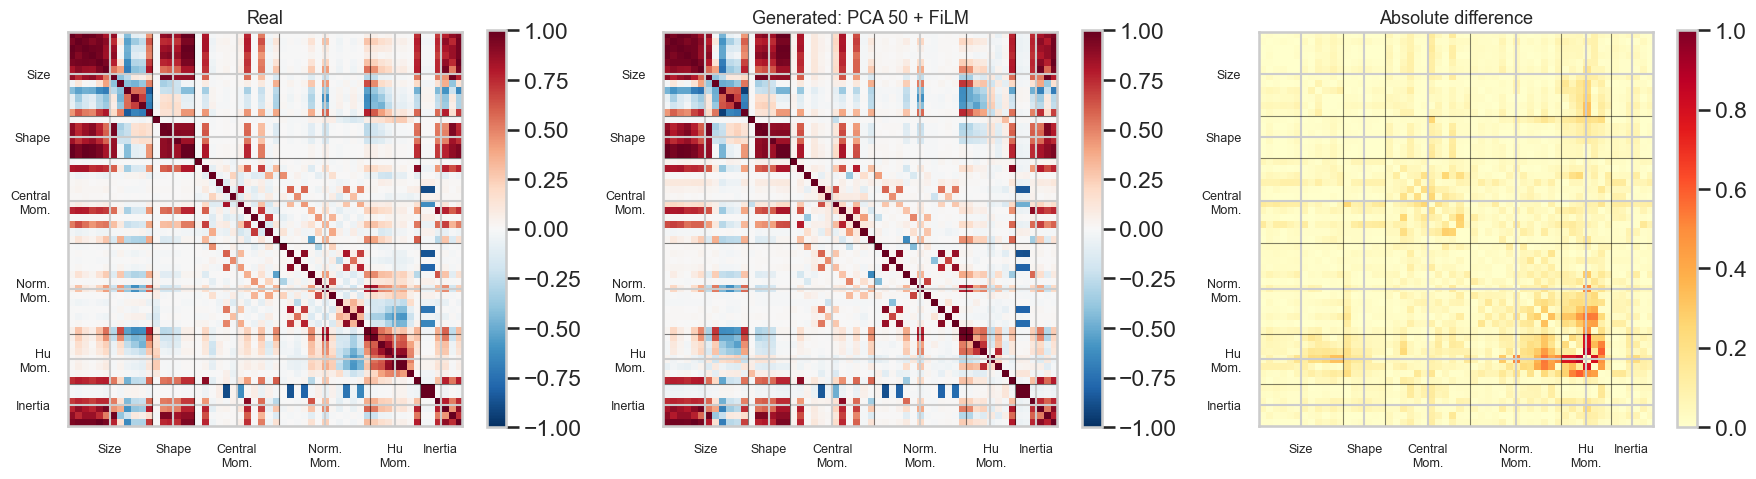

In [21]:
import matplotlib.pyplot as plt
import numpy as np

corr_real = np.corrcoef(y_real.T)
corr_gen = np.corrcoef(y_best.T)
corr_diff = np.abs(corr_real - corr_gen)

groups = [
    ("Size", 0, 12),
    ("Shape", 12, 18),
    ("Central\nMom.", 18, 30),
    ("Norm.\nMom.", 30, 43),
    ("Hu\nMom.", 43, 50),
    ("Inertia", 50, 56),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

for ax, (matrix, title) in zip(
    axes,
    [
        (corr_real, "Real"),
        (corr_gen, "Generated: PCA 50 + FiLM"),
        (corr_diff, "Absolute difference"),
    ],
):
    if title == "Absolute difference":
        im = ax.imshow(matrix, cmap="YlOrRd", vmin=0, vmax=1)
    else:
        im = ax.imshow(matrix, cmap="RdBu_r", vmin=-1, vmax=1)

    ax.set_title(title, fontsize=13)
    fig.colorbar(im, ax=ax, shrink=0.8)

    tick_positions = []
    tick_labels = []

    for name, start, end in groups:
        mid = (start + end - 1) / 2
        tick_positions.append(mid)
        tick_labels.append(name)

        if start > 0:
            ax.axhline(start - 0.5, color="black", linewidth=0.8, alpha=0.5)
            ax.axvline(start - 0.5, color="black", linewidth=0.8, alpha=0.5)

    ax.set_xticks(tick_positions)
    ax.set_xticklabels(tick_labels, fontsize=9)
    ax.set_yticks(tick_positions)
    ax.set_yticklabels(tick_labels, fontsize=9)

plt.tight_layout()

path = FIGURE_DIR / "slide13_correlation_matrices_labeled_pca50_film.png"
plt.savefig(path, dpi=300, bbox_inches="tight")
print(f"Saved {path}")

plt.show()

## Slide 13B: nW1 by Feature Group

In [8]:
FEATURE_GROUPS = {
    "Size": [
        "Area", "BoundingBoxArea", "ConvexArea", "EquivalentDiameter",
        "Perimeter", "PerimeterCrofton", "MajorAxisLength", "MinorAxisLength",
        "MaximumRadius", "MeanRadius", "MedianRadius", "FilledArea",
    ],
    "Shape": [
        "Eccentricity", "FormFactor", "Extent", "Solidity", "Compactness",
        "EulerNumber",
    ],
    "Central Moments": [
        "CentralMoment_0_0", "CentralMoment_0_1", "CentralMoment_0_2",
        "CentralMoment_0_3", "CentralMoment_1_0", "CentralMoment_1_1",
        "CentralMoment_1_2", "CentralMoment_1_3", "CentralMoment_2_0",
        "CentralMoment_2_1", "CentralMoment_2_2", "CentralMoment_2_3",
    ],
    "Normalized Moments": [
        "NormalizedMoment_0_2", "NormalizedMoment_0_3",
        "NormalizedMoment_1_1", "NormalizedMoment_1_2",
        "NormalizedMoment_1_3", "NormalizedMoment_2_0",
        "NormalizedMoment_2_1", "NormalizedMoment_2_2",
        "NormalizedMoment_2_3", "NormalizedMoment_3_0",
        "NormalizedMoment_3_1", "NormalizedMoment_3_2",
        "NormalizedMoment_3_3",
    ],
    "Hu Moments": [
        "HuMoment_0", "HuMoment_1", "HuMoment_2", "HuMoment_3",
        "HuMoment_4", "HuMoment_5", "HuMoment_6",
    ],
    "Inertia": [
        "InertiaTensor_0_0", "InertiaTensor_0_1",
        "InertiaTensor_1_0", "InertiaTensor_1_1",
        "InertiaTensorEigenvalues_0", "InertiaTensorEigenvalues_1",
    ],
}

feature_to_group = {
    feature: group
    for group, features in FEATURE_GROUPS.items()
    for feature in features
    if feature in morph_cols
}
missing_group = sorted(set(morph_cols) - set(feature_to_group))
print(f"Ungrouped features: {missing_group}")

best_feature_metrics = feature_metrics[feature_metrics["model"] == BEST_MODEL].copy()
best_feature_metrics["feature_group"] = best_feature_metrics["feature"].map(feature_to_group).fillna("Other")

group_metrics = (
    best_feature_metrics
    .groupby("feature_group", as_index=False)
    .agg(
        mean_normalized_w1=("normalized_w1", "mean"),
        median_normalized_w1=("normalized_w1", "median"),
        n_features=("feature", "count"),
    )
)
group_order = [group for group in FEATURE_GROUPS if group in set(group_metrics["feature_group"])]
if "Other" in set(group_metrics["feature_group"]):
    group_order.append("Other")
group_metrics["feature_group"] = pd.Categorical(group_metrics["feature_group"], categories=group_order, ordered=True)
group_metrics = group_metrics.sort_values("feature_group")
group_metrics.to_csv(FIGURE_DIR / "slide13_feature_group_nw1.csv", index=False)
display(group_metrics.style.format({"mean_normalized_w1": "{:.3f}", "median_normalized_w1": "{:.3f}"}))

Ungrouped features: []


,feature_group,mean_normalized_w1,median_normalized_w1,n_features
5,Size,0.110,0.092,12
4,Shape,0.131,0.143,6
0,Central Moments,0.061,0.057,12
3,Normalized Moments,0.105,0.102,13
1,Hu Moments,0.089,0.090,7
2,Inertia,0.103,0.105,6


Saved /Users/hannesneumann/Repositories/conditional-flow-matching-seminar/outputs/test_prediction_visuals/slide13_feature_group_nw1_pca50_film.png
Saved /Users/hannesneumann/Repositories/conditional-flow-matching-seminar/outputs/test_prediction_visuals/slide13_feature_group_nw1_pca50_film.svg


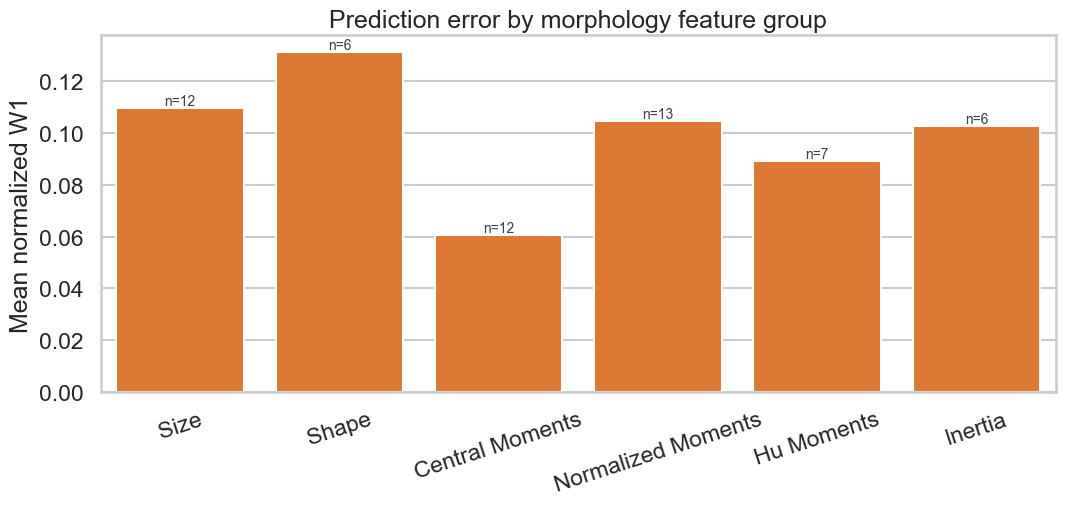

In [9]:
fig, ax = plt.subplots(figsize=(11, 5.4))
sns.barplot(
    data=group_metrics,
    x="feature_group",
    y="mean_normalized_w1",
    color=BAR_COLOR,
    ax=ax,
)
ax.set_xlabel("")
ax.set_ylabel("Mean normalized W1")
ax.set_title("Prediction error by morphology feature group")
ax.tick_params(axis="x", rotation=18)

for patch, (_, row) in zip(ax.patches, group_metrics.iterrows()):
    ax.text(
        patch.get_x() + patch.get_width() / 2,
        patch.get_height(),
        f"n={int(row['n_features'])}",
        ha="center",
        va="bottom",
        fontsize=10,
        color="#374151",
    )

plt.tight_layout()
for suffix in ["png", "svg"]:
    path = FIGURE_DIR / f"slide13_feature_group_nw1_pca50_film.{suffix}"
    fig.savefig(path, dpi=300, bbox_inches="tight")
    print(f"Saved {path}")
plt.show()

## Optional: Feature-Level Diagnostics

In [10]:
top_worst = best_feature_metrics.sort_values("normalized_w1", ascending=False).head(15)
top_best = best_feature_metrics.sort_values("normalized_w1", ascending=True).head(15)

display(top_worst[["feature", "feature_group", "normalized_w1", "w1", "real_std"]].style.format({"normalized_w1": "{:.3f}", "w1": "{:.3g}", "real_std": "{:.3g}"}))
display(top_best[["feature", "feature_group", "normalized_w1", "w1", "real_std"]].style.format({"normalized_w1": "{:.3f}", "w1": "{:.3g}", "real_std": "{:.3g}"}))

,feature,feature_group,normalized_w1,w1,real_std
239,MedianRadius,Size,0.271,0.105,0.387
235,Compactness,Shape,0.182,0.045,0.247
266,HuMoment_0,Hu Moments,0.172,0.00759,0.0441
232,FormFactor,Shape,0.161,0.033,0.205
260,NormalizedMoment_2_2,Normalized Moments,0.160,0.00119,0.00742
233,Extent,Shape,0.148,0.0147,0.0987
231,Eccentricity,Shape,0.138,0.0217,0.157
277,InertiaTensorEigenvalues_0,Inertia,0.134,1.07,7.97
237,MaximumRadius,Size,0.134,0.14,1.05
229,MajorAxisLength,Size,0.130,0.542,4.16


,feature,feature_group,normalized_w1,w1,real_std
242,CentralMoment_0_1,Central Moments,0.029,2.88e-10,3.39e-14
245,CentralMoment_1_0,Central Moments,0.029,2.91e-10,4.21e-14
270,HuMoment_4,Hu Moments,0.031,5e-06,0.00016
244,CentralMoment_0_3,Central Moments,0.033,57.1,1.72e+03
272,HuMoment_6,Hu Moments,0.041,2.45e-07,6.02e-06
252,CentralMoment_2_3,Central Moments,0.042,3.47e+03,8.37e+04
271,HuMoment_5,Hu Moments,0.043,6.33e-05,0.00147
248,CentralMoment_1_3,Central Moments,0.054,1.79e+03,3.35e+04
250,CentralMoment_2_1,Central Moments,0.057,57,1.01e+03
247,CentralMoment_1_2,Central Moments,0.057,52.4,920
